Sales Data Analysis Project

1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

2. Data Loading

In [5]:
def load_data(file_path="sales_data_sample.csv", encoding="latin1"):
    """
    Load sales data CSV with encoding fallback.
    Default encoding: latin1
    Fallback: ISO-8859-1
    """
    try:
        df = pd.read_csv(file_path, encoding=encoding)
    except UnicodeDecodeError:
        df = pd.read_csv(file_path, encoding="ISO-8859-1")
    return df


3. Data Cleaning & Preprocessing

In [6]:
def clean_data(df):
    # Rename Kaggle columns to match project code
    df = df.rename(columns={
        'ORDERDATE': 'Date',
        'QUANTITYORDERED': 'Quantity',
        'PRICEEACH': 'Price',
        'SALES': 'Revenue',
        'PRODUCTLINE': 'Product'
    })
    

    # Convert date column to datetime
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    
      # Ensure numeric columns are correct
    df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
    df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
    df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')
    
        # Drop rows with missing values
    df = df.dropna()
    
    return df


4. Feature Extraction (Monthly Trends)

In [7]:
def extract_features(df):
    df['Month'] = df['Date'].dt.to_period('M')
    monthly_sales = df.groupby('Month')['Revenue'].sum().reset_index()
    return monthly_sales

5. Exploratory Data Analysis (EDA) & Visualization

Top Selling Products

In [8]:
def plot_top_products(df):
    top_products = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(10)
    plt.figure(figsize=(10,6))
    sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")
    plt.title("Top Selling Products")
    plt.xlabel("Revenue")
    plt.ylabel("Product")
    plt.show()
    print("Insight: The top product contributes significantly to overall revenue, indicating a strong dependency.")

Monthly Sales Trend

In [9]:
def plot_monthly_trend(monthly_sales):
    plt.figure(figsize=(10,6))
    sns.lineplot(x=monthly_sales['Month'].astype(str), y=monthly_sales['Revenue'], marker="o")
    plt.title("Monthly Sales Trend")
    plt.xlabel("Month")
    plt.ylabel("Revenue")
    plt.xticks(rotation=45)
    plt.show()
    print("Insight: Seasonal peaks are visible, suggesting demand fluctuations across months.")

Revenue Distribution

In [10]:
def plot_revenue_distribution(df):
    product_revenue = df.groupby('Product')['Revenue'].sum()
    plt.figure(figsize=(8,8))
    plt.pie(product_revenue, labels=product_revenue.index, autopct='%1.1f%%', startangle=140)
    plt.title("Revenue Distribution by Product")
    plt.show()
    print("Insight: Revenue is concentrated among a few products, highlighting key drivers of sales.")

6. Streamlit Dashboard

In [11]:
def run_dashboard(df, monthly_sales):
    st.title("📊 Sales Data Analysis Dashboard")

    # KPIs
    total_revenue = df['Revenue'].sum()
    top_product = df.groupby('Product')['Revenue'].sum().idxmax()
    
    st.metric("Total Revenue", f"${total_revenue:,.2f}")
    st.metric("Top Product", top_product)

    # Interactive Charts
    st.subheader("Top Selling Products")
    top_products = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(10)
    st.bar_chart(top_products)

    st.subheader("Monthly Sales Trend")
    st.line_chart(monthly_sales.set_index('Month'))

    st.subheader("Revenue Distribution")
    st.write("Revenue share among products")
    st.pyplot(plot_revenue_distribution(df))

7. Main Function

C:\Users\user\AppData\Local\Temp\ipykernel_3960\1539284967.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")


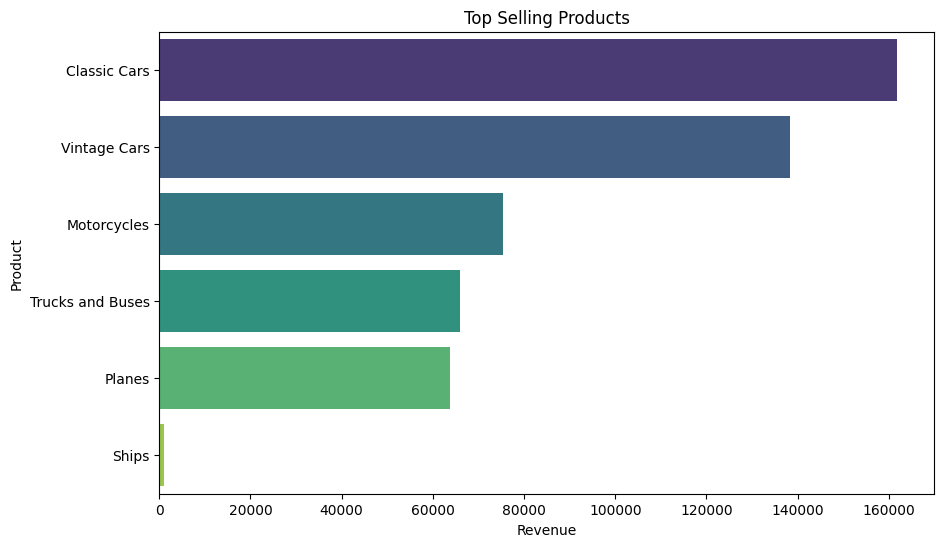

Insight: The top product contributes significantly to overall revenue, indicating a strong dependency.


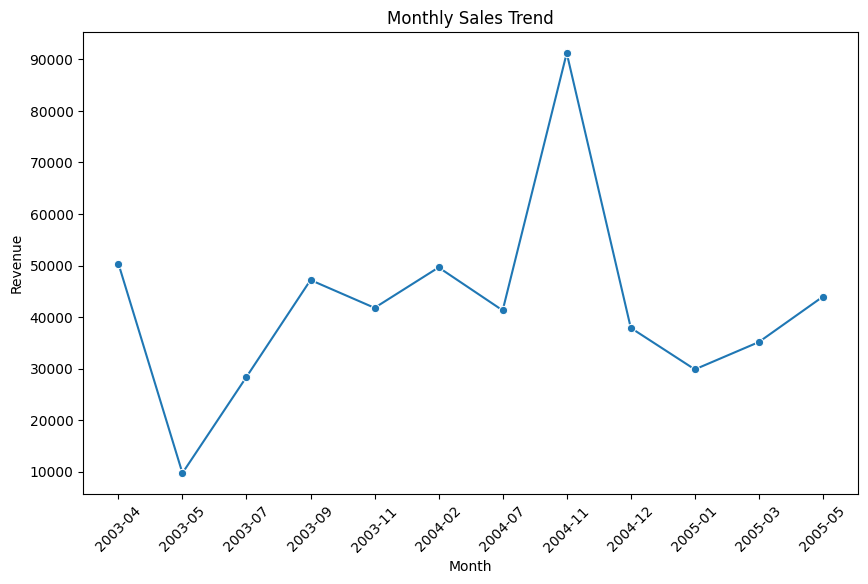

Insight: Seasonal peaks are visible, suggesting demand fluctuations across months.


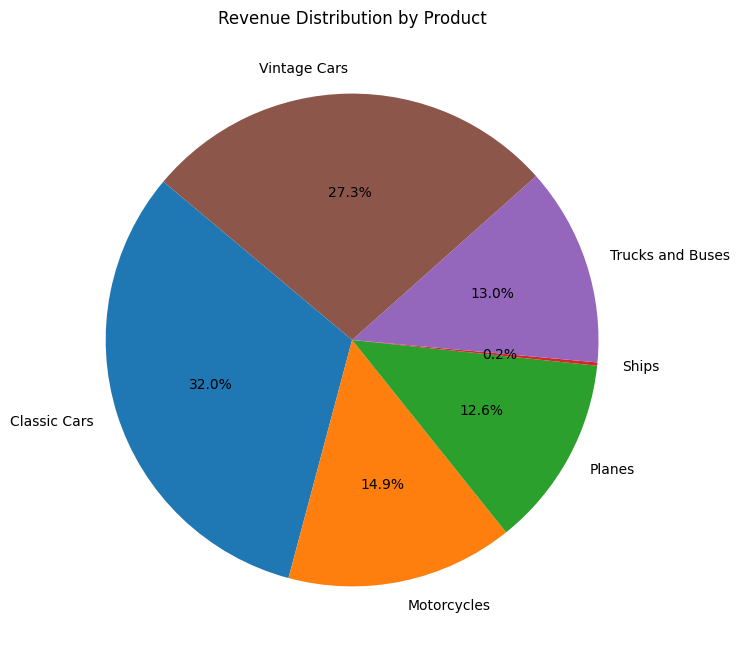

2026-03-30 18:48:48.956 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Insight: Revenue is concentrated among a few products, highlighting key drivers of sales.


2026-03-30 18:48:49.389 
  command:

    streamlit run C:\Users\user\AppData\Roaming\Python\Python314\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-30 18:48:49.390 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 18:48:49.391 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 18:48:49.398 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 18:48:49.399 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 18:48:49.400 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 18:48:49.402 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 18:48:49.403 Thread 'MainThread': missing ScriptRunContext! This warning can be ign

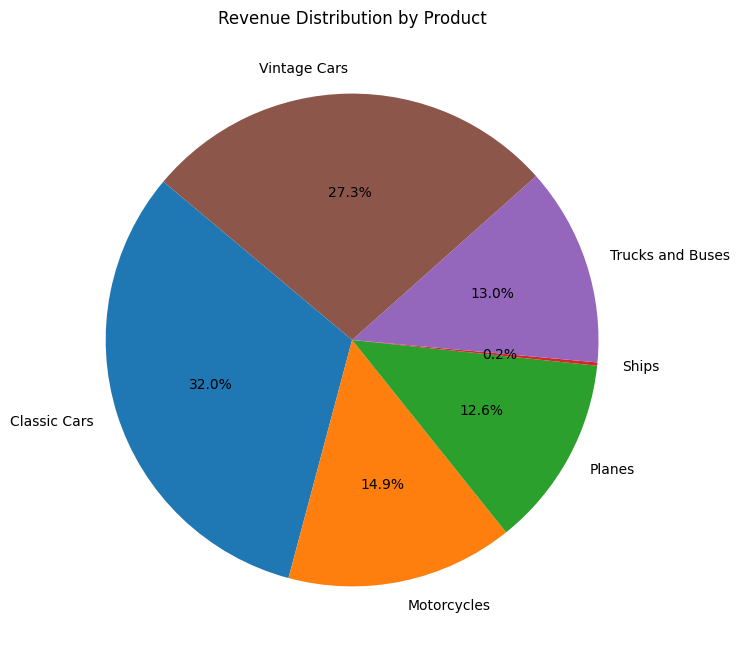

2026-03-30 18:48:56.937 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 18:48:56.937 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 18:48:56.938 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 18:48:56.939 
Calling `st.pyplot()` without providing a figure argument has been deprecated
and will be removed in a later version as it requires the use of Matplotlib's
global figure object, which is not thread-safe.

To future-proof this code, you should pass in a figure as shown below:

```python
fig, ax = plt.subplots()
ax.scatter([1, 2, 3], [1, 2, 3])
# other plotting actions...
st.pyplot(fig)
```

If you have a specific use case that requires this functionality, please let us
know via [issue on Github](https://github.com/streamlit/streamlit/issues).

2026-03-30 18:48:56.939 Thread 'MainThread': mis

Insight: Revenue is concentrated among a few products, highlighting key drivers of sales.


<Figure size 640x480 with 0 Axes>

In [ ]:
def main():
    df = load_data("sales_data_sample.csv")
    df = clean_data(df)
    monthly_sales = extract_features(df)
    
    # Static Analysis
    plot_top_products(df)
    plot_monthly_trend(monthly_sales)
    plot_revenue_distribution(df)
    
    # Streamlit Dashboard
    run_dashboard(df, monthly_sales)

if __name__ == "__main__":
    main()